In [1]:
# Array and data functions
from glob import glob
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

from MEDUSSA.measure import SizeDataFrame
from MEDUSSA.transform import ParamSampler
from MEDUSSA.utils import Relabeler,BorderRemoval,IntersectionKDE

from skimage import io

import warnings
warnings.filterwarnings('ignore')

In [2]:
manual_masks = sorted(glob('/Volumes/evocell/Octavio/Omnipose/Benchmarking/Test_masks/*.tif'))
omnipose_masks = sorted(glob('/Volumes/evocell/Octavio/Omnipose/Benchmarking/omnipose_deconvolved_masks/masks_GUI/0*'))

print(len(manual_masks))

assert len(manual_masks) == len(omnipose_masks)

manual_masks = [io.imread(mask) for mask in manual_masks]

# Remove border segmentations
omnipose_masks = [BorderRemoval(io.imread(mask)) for mask in omnipose_masks]


16


In [3]:
manual_cells = SizeDataFrame(manual_masks,from_paths=False)
manual_cells.insert(0,'Method','Manual')

relabeled_masks = [Relabeler(manual,omni) for manual,omni in zip(manual_masks,omnipose_masks)]

omnipose_cells = SizeDataFrame(relabeled_masks,from_paths=False)
omnipose_cells.insert(0,'Method','Automatic')
omnipose_cells = omnipose_cells[omnipose_cells['Width'] > 0.3]

In [4]:
df_posteriors = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Figures/FigureS4/posterior_segmentation_measurements.csv')

metrics = ['Width','Length','SurfaceArea','Volume']

sampled_df_automatic = ParamSampler(omnipose_cells,df_posteriors,columns=['Method'],metrics=metrics)

In [5]:
w0 = np.array(manual_cells['Width'])
w1 = np.array(omnipose_cells['Width'])
w2 = np.array(sampled_df_automatic['Width_mu'])

w01,kde_w0,kde_w1,inters_w01 = IntersectionKDE(w0,w1)
w02,kde_w0,kde_w2,inters_w02 = IntersectionKDE(w0,w2)

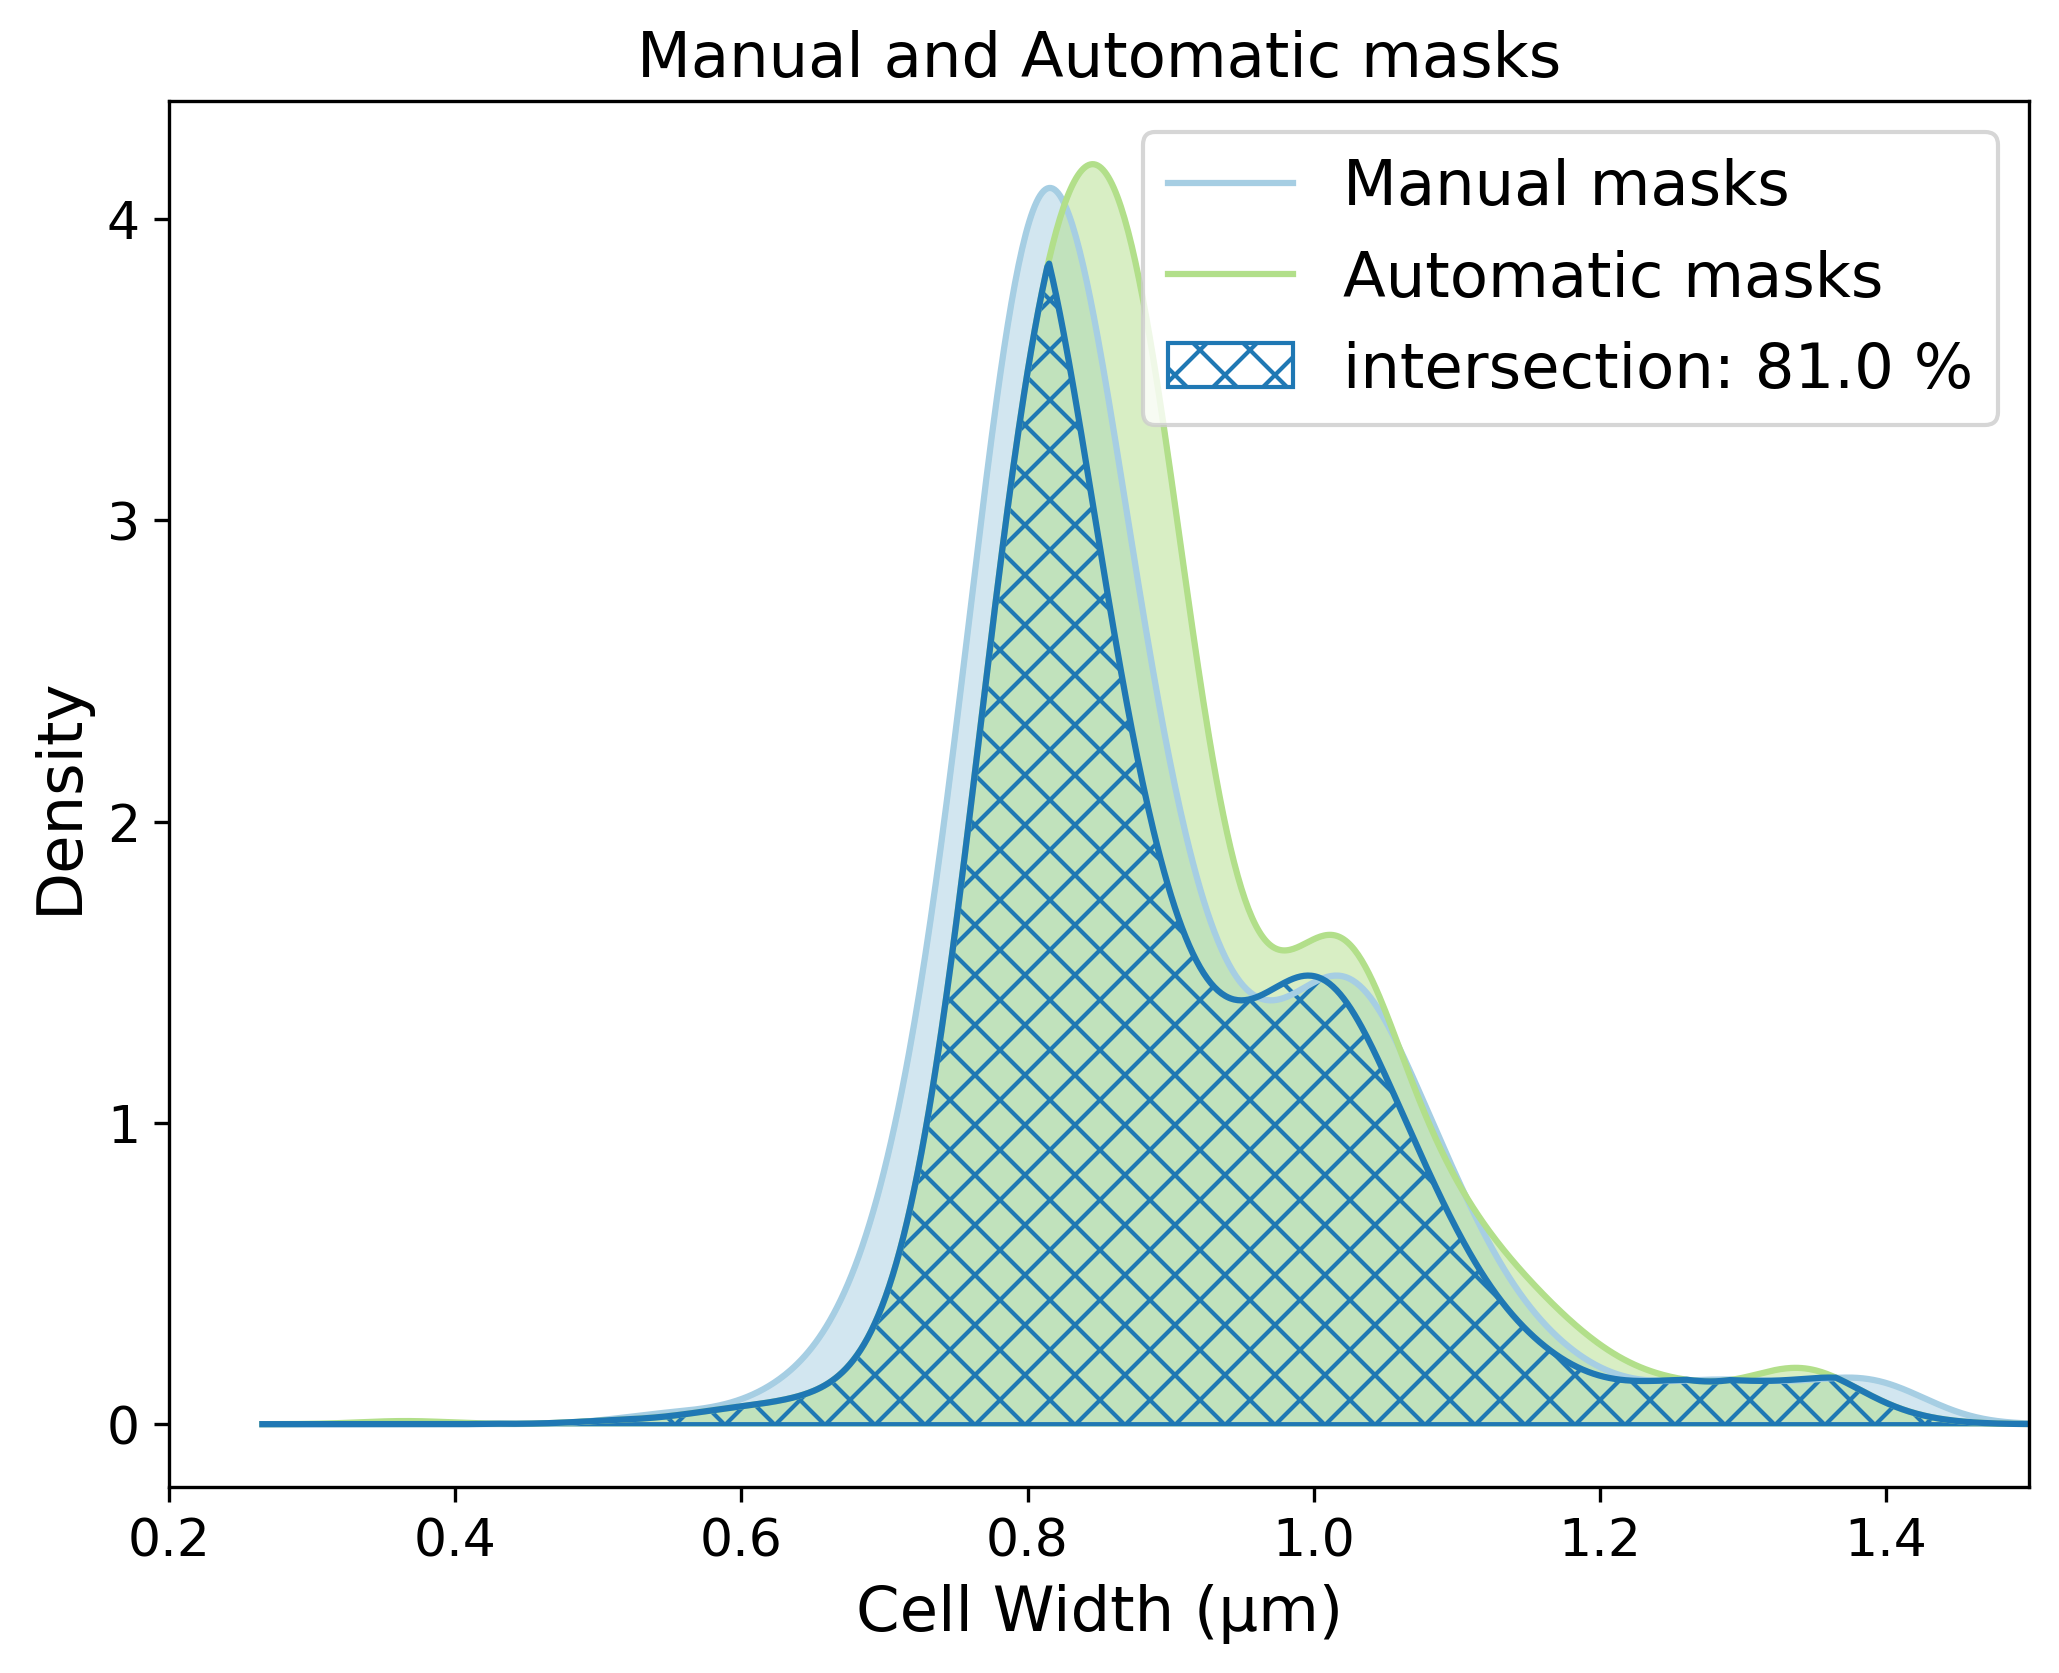

In [6]:
fig,ax = plt.subplots(dpi=300,figsize=(8,6))
    
ax.plot(w01, kde_w0, color='#a6cee3', label='Manual masks')
ax.fill_between(w01, kde_w0, 0, color='#a6cee3', alpha=0.5)
ax.plot(w01, kde_w1, color='#b2df8a', label='Automatic masks')
ax.fill_between(w01, kde_w1, 0, color='#b2df8a', alpha=0.5)
ax.plot(w01, inters_w01, color='#1f78b4')
ax.fill_between(w01, inters_w01, 0, facecolor='none', edgecolor='#1f78b4', hatch='xx', label='intersection')

handles, labels = ax.get_legend_handles_labels()
labels[2] += f': {np.trapezoid(inters_w01, w01) * 100:.1f} %'

ax.legend(handles, labels,fontsize=15)
ax.set_xlabel('Cell Width (µm)',fontsize=15)
ax.set_ylabel('Density',fontsize=15)
ax.set_xlim(0.2,1.5)
ax.set_title(f'Manual and Automatic masks',fontsize=15)
ax.set_xticklabels(ax.get_xticklabels(),fontsize=12.5) 
ax.set_yticklabels(ax.get_yticklabels(),fontsize=12.5) 

fig.savefig('/Users/reyesmatte/Desktop/Imaging_paper/Fig4/Intersection_KDE_MA.png')

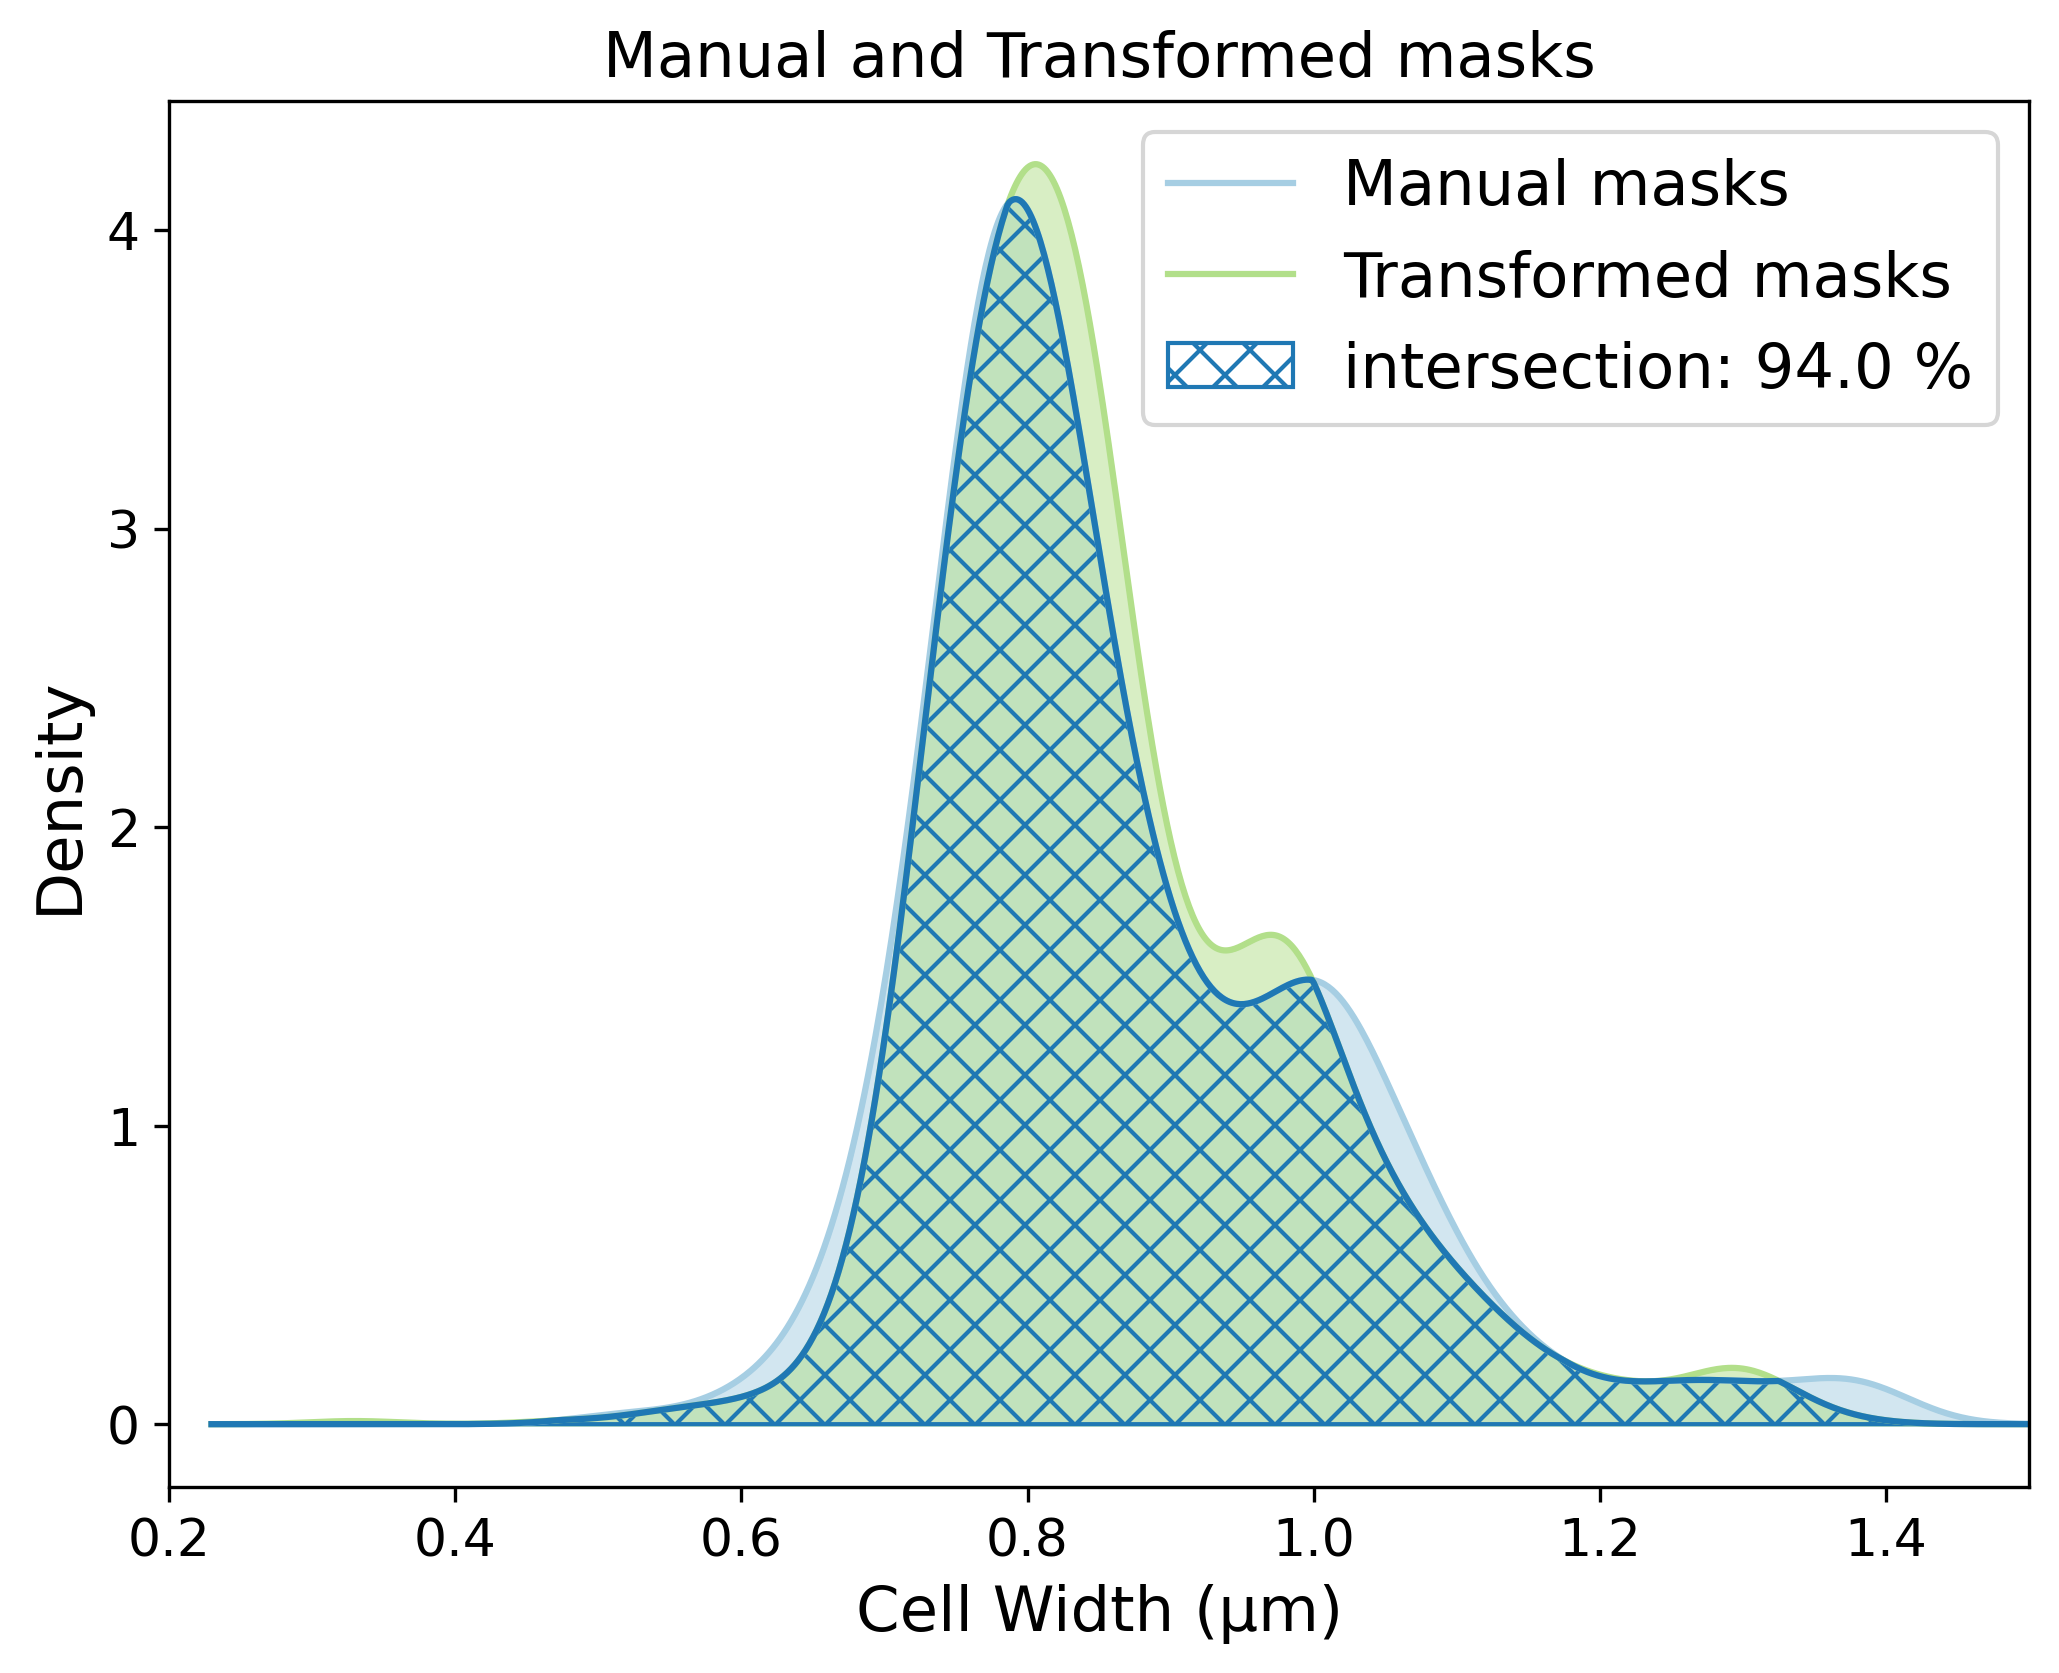

In [7]:
fig,ax = plt.subplots(dpi=300,figsize=(8,6))
    
ax.plot(w02, kde_w0, color='#a6cee3', label='Manual masks')
ax.fill_between(w02, kde_w0, 0, color='#a6cee3', alpha=0.5)
ax.plot(w02, kde_w2, color='#b2df8a', label='Transformed masks')
ax.fill_between(w02, kde_w2, 0, color='#b2df8a', alpha=0.5)
ax.plot(w02, inters_w02, color='#1f78b4')
ax.fill_between(w02, inters_w02, 0, facecolor='none', edgecolor='#1f78b4', hatch='xx', label='intersection')

handles, labels = ax.get_legend_handles_labels()
labels[2] += f': {np.trapezoid(inters_w02, w02) * 100:.1f} %'

ax.legend(handles, labels,fontsize=15)
ax.set_xlabel('Cell Width (µm)',fontsize=15)
ax.set_ylabel('Density',fontsize=15)
ax.set_xlim(0.2,1.5)
ax.set_title(f'Manual and Transformed masks',fontsize=15)
ax.set_xticklabels(ax.get_xticklabels(),fontsize=12.5) 
ax.set_yticklabels(ax.get_yticklabels(),fontsize=12.5) 

fig.savefig('/Users/reyesmatte/Desktop/Imaging_paper/Fig4/Intersection_KDE_MT.png')